# Exploratory Data Analysis (EDA)

## I. Introduction

This capstone project explores the Olist E-commerce dataset, which captures the full lifecycle of orders from a Brazilian online marketplace. The dataset merges customer, seller, order, product, review, and payment data to enable insights into delivery delays, seller behavior, and customer segmentation.

Our goal is to analyze delivery bottlenecks, identify patterns in seller handoffs, and understand customer behavior to improve platform reliability and user satisfaction.


## II. Load Raw Datasets

We begin by loading each raw dataset provided by Olist, including orders, customers, payments, reviews, sellers, and products. This step helps us understand the structure and prepare for merging.


In [1]:
import pandas as pd

# Load each dataset from CSV files
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/raw/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')

# Display the shape of each dataset
print("Customers:", customers.shape)
print("Geolocation:", geolocation.shape)
print("Order Items:", order_items.shape)
print("Order Payments:", order_payments.shape)
print("Order Reviews:", order_reviews.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)


Customers: (99441, 5)
Geolocation: (1000163, 5)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Sellers: (3095, 4)


## III. Merge Datasets

In this step, we merge the raw datasets into a single unified DataFrame using `orders` as the central table.  
We will join customers, order items, products, sellers, payments, and reviews using appropriate keys like `order_id`, `customer_id`, and `product_id`.


In [2]:
# Step 1: Start with orders
df = orders.copy()

# Step 2: Merge with customers (on customer_id)
df = df.merge(customers, on='customer_id', how='left')

# Step 3: Merge with order_items (on order_id)
df = df.merge(order_items, on='order_id', how='left')

# Step 4: Merge with products (on product_id)
df = df.merge(products, on='product_id', how='left')

# Step 5: Merge with sellers (on seller_id)
df = df.merge(sellers, on='seller_id', how='left')

# Step 6: Merge with payments (on order_id)
df = df.merge(order_payments, on='order_id', how='left')

# Step 7: Merge with reviews (on order_id)
df = df.merge(order_reviews, on='order_id', how='left')

# Check shape and preview
print(df.shape)
df.head()


(119143, 39)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


## IV. Basic Data Overview

Before diving into analysis, we examine the structure of the merged dataset.  
This includes checking the number of columns and rows, identifying column types, and spotting missing values.


In [3]:
# Check shape and columns
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Check data types and non-null counts
df.info()


Shape: (119143, 39)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Nul

In [4]:
# Check missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print(missing)



Missing values per column:
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853
product_width_cm                    853
seller_zip_code_prefix              833
seller_city                         833
seller_state                        833
payment_sequential                    3
payment_type                          3
payment_installments                  3
payment_value                         3
review_id    

## V. Data Cleaning

To ensure accurate and reliable analysis, we clean the merged dataset by addressing inconsistencies and formatting issues.

### Cleaning Steps:

1. **Standardize City Names**: Normalize common spelling variations such as "Sao Paulo" → "São Paulo"
2. **Trim Whitespace & Lowercase Standardization**: Remove leading/trailing spaces and unify string formatting.
3. **Drop Nulls**: Remove rows with missing values in critical columns for analysis.
4. **Outlier Handling**: Optionally filter out extreme values in `price`, `freight_value`, or product dimensions.


In [5]:
from unidecode import unidecode

# Convert to string and remove accents for both customer and seller cities
df['customer_city'] = df['customer_city'].fillna('').astype(str).apply(unidecode)
df['seller_city'] = df['seller_city'].fillna('').astype(str).apply(unidecode)

# 2. Trim whitespace and lowercase for consistency
str_columns = ['customer_city', 'customer_state', 'seller_city', 'seller_state', 'payment_type']
for col in str_columns:
    df[col] = df[col].str.strip().str.lower()

# 3. Drop rows with missing values in key columns
critical_columns = ['order_id', 'customer_id', 'order_status', 'price', 'freight_value']
df = df.dropna(subset=critical_columns)

# 4. Remove extreme outliers in price and freight_value
price_threshold = df['price'].quantile(0.995)
freight_threshold = df['freight_value'].quantile(0.995)

df = df[(df['price'] <= price_threshold) & (df['freight_value'] <= freight_threshold)]


## VI. Create Delivery Delay Indicator

To evaluate delivery delays, we compare the actual delivery date (`order_delivered_customer_date`) to the estimated date (`order_estimated_delivery_date`).  
We create a binary column `delivered_late` to flag whether the delivery was late.


In [6]:
# Convert delivery dates to datetime
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Create 'delivered_late' column
df['delivered_late'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

# Handle missing dates (avoid True/False on NaT)
df['delivered_late'] = df['delivered_late'].fillna(False)

# Check distribution
print(df['delivered_late'].value_counts(normalize=True))


delivered_late
False    0.923771
True     0.076229
Name: proportion, dtype: float64


### A. Price vs Delivered Late

We compare the distribution of product prices between on-time and late deliveries using a boxplot.


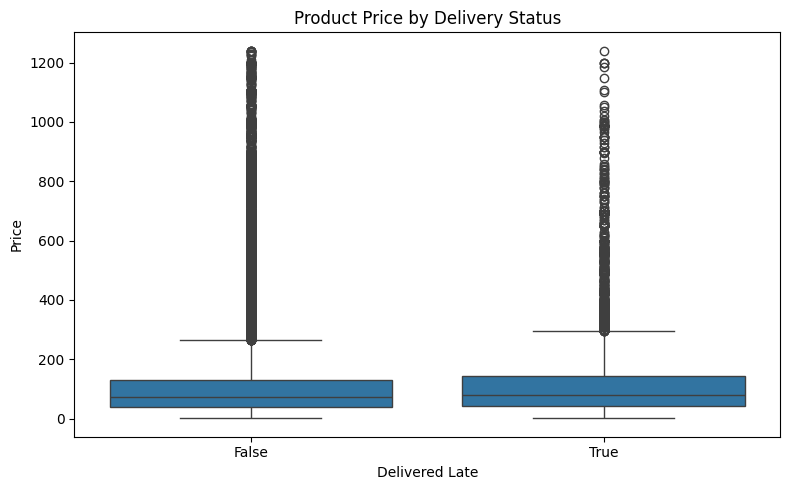

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for price vs delivery status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='delivered_late', y='price')
plt.title('Product Price by Delivery Status')
plt.xlabel('Delivered Late')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


The boxplot compares product prices between on-time and late deliveries.

We observe that the price distribution is relatively similar for both groups, with no significant shift in median or spread.  
Both categories contain extreme outliers (high-price items), but these do not appear to strongly influence whether a delivery is delayed.

This suggests that product price alone is not a key driver of delivery delays.


### B. Top Product Categories by Late Delivery Rate

We analyze which product categories have the highest proportion of late deliveries.


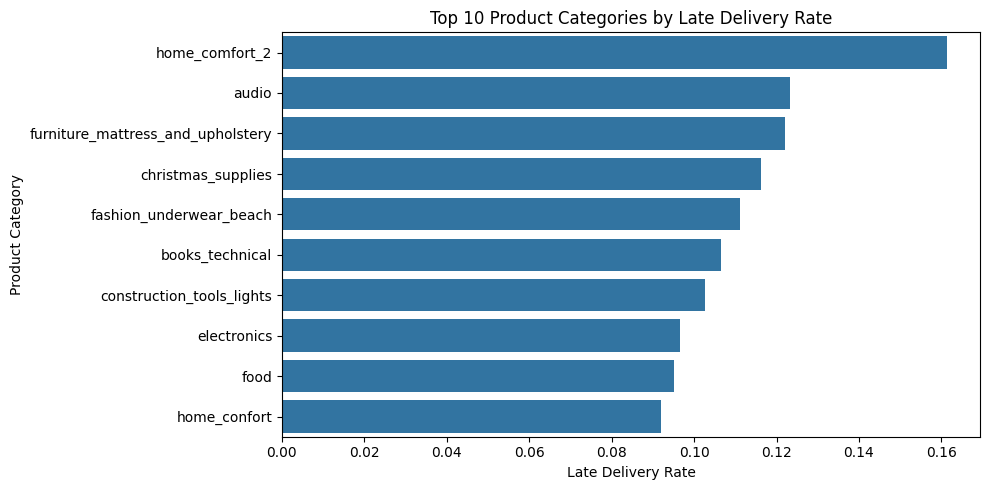

In [8]:
# Load translation file
category_translation = pd.read_csv('../data/raw/product_category_name_translation.csv')

# Merge with main dataframe on 'product_category_name'
df = df.merge(category_translation, on='product_category_name', how='left')

# Calculate late delivery rate by English product category name
late_by_category = df.groupby('product_category_name_english')['delivered_late'].mean().sort_values(ascending=False).head(10)

# Barplot
plt.figure(figsize=(10, 5))
sns.barplot(x=late_by_category.values, y=late_by_category.index)
plt.title('Top 10 Product Categories by Late Delivery Rate')
plt.xlabel('Late Delivery Rate')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


The bar chart highlights the top 10 product categories with the highest late delivery rates.

Categories like `home_comfort_2`, `audio`, and `furniture_mattress_and_upholstery` stand out with delay rates exceeding 10–15%.  
These categories likely involve bulky or fragile items that require special handling, which may contribute to logistical challenges and delivery delays.

This insight helps identify product types that may need better inventory or shipping management to reduce customer dissatisfaction.


## VII. Analyze Seller Handoff Delays

We define `handoff_delay` as the number of days between the order approval date and the date the seller hands off the order to the carrier.  
This helps identify how promptly sellers process orders for shipment.


In [9]:
# Convert relevant columns to datetime
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])

# Calculate handoff delay in days
df['handoff_delay'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.days

# Check basic stats
print(df['handoff_delay'].describe())


count    115978.000000
mean          2.336685
std           3.537770
min        -172.000000
25%           0.000000
50%           1.000000
75%           3.000000
max         101.000000
Name: handoff_delay, dtype: float64


### A. Distribution of Seller Handoff Delay

We visualize the distribution of handoff delays to understand how quickly sellers process orders.  
Extreme outliers (e.g., delays over 15 days or negative delays) will be excluded for better clarity.


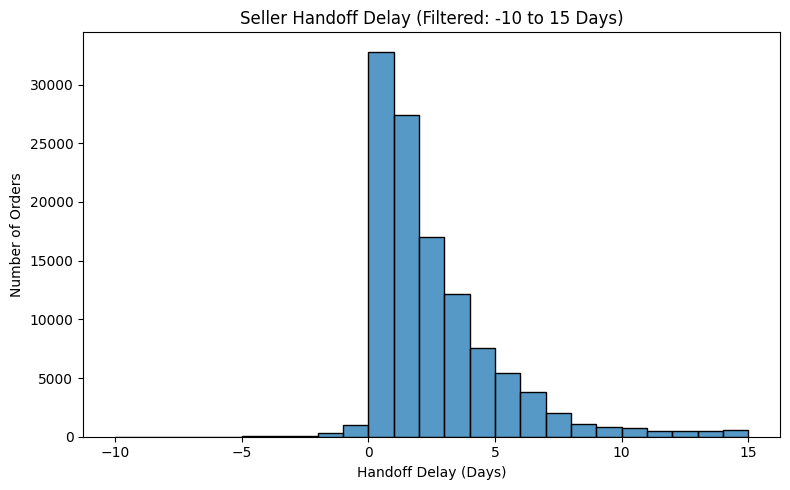

In [10]:
# Filter handoff_delay between -10 and 15 days for cleaner visualization
filtered = df[(df['handoff_delay'] >= -10) & (df['handoff_delay'] <= 15)]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(filtered['handoff_delay'], bins=25, kde=False)
plt.title('Seller Handoff Delay (Filtered: -10 to 15 Days)')
plt.xlabel('Handoff Delay (Days)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


The histogram shows the distribution of seller handoff delays, filtered between -10 and 15 days for clarity.

Most sellers hand off orders within 1 to 3 days after approval, with a noticeable right-skewed tail indicating longer delays in some cases.  
The concentration around 0–3 days suggests that sellers generally process orders promptly, but a non-negligible number experience delays up to two weeks.

Understanding this distribution helps flag inefficient sellers and anticipate delivery risk.


### B. Relationship Between Handoff Delay and Delivery Delay

To determine if seller delays impact final delivery outcomes, we compare handoff delays for orders that were delivered late versus on time.


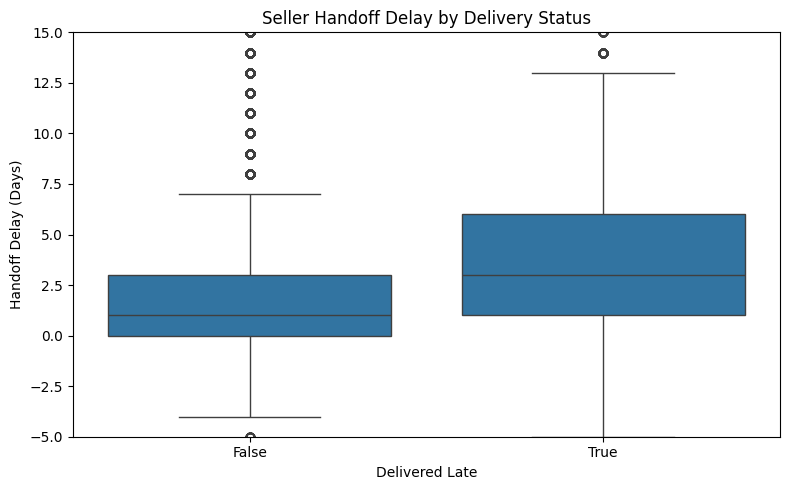

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='delivered_late', y='handoff_delay', data=df)
plt.title('Seller Handoff Delay by Delivery Status')
plt.xlabel('Delivered Late')
plt.ylabel('Handoff Delay (Days)')
plt.ylim(-5, 15)  # Adjust based on your typical range
plt.tight_layout()
plt.show()


The boxplot above illustrates the distribution of seller handoff delays for on-time (`False`) and late (`True`) deliveries. 

We observe that orders with late deliveries tend to have a higher median handoff delay and a wider spread compared to on-time deliveries. This suggests that delays in passing orders from sellers to carriers may contribute to overall delivery lateness.


### C. Top Sellers by Average Handoff Delay

To identify sellers who may be contributing to delivery delays, we calculate the average handoff delay for each seller.  
This helps pinpoint which sellers are consistently slower in processing and handing off orders to the carrier.

By highlighting these sellers, the platform can target process improvements or performance reviews to improve shipping reliability.


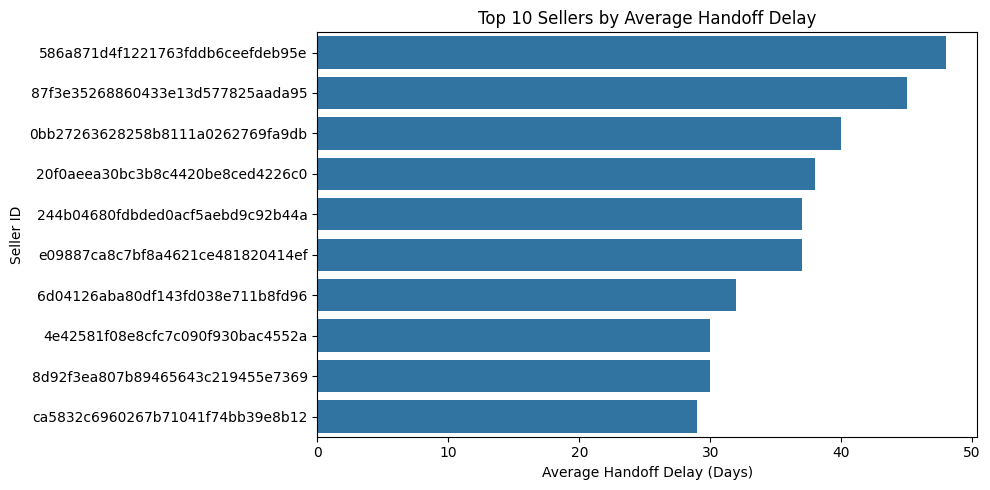

In [12]:
# Calculate average handoff delay by seller
top_sellers_delay = df.groupby('seller_id')['handoff_delay'].mean().sort_values(ascending=False).head(10)

# Plot bar chart of top 10 sellers with highest average handoff delay
plt.figure(figsize=(10, 5))
sns.barplot(x=top_sellers_delay.values, y=top_sellers_delay.index)
plt.title('Top 10 Sellers by Average Handoff Delay')
plt.xlabel('Average Handoff Delay (Days)')
plt.ylabel('Seller ID')
plt.tight_layout()
plt.show()


This bar chart shows the top 10 sellers with the highest average handoff delays — the time between order approval and the handoff to the carrier.

Each bar represents a seller (anonymized by ID) and their average delay in days. Sellers at the top of the chart consistently take longer to process orders, which may contribute to delivery delays.

These insights can help the platform identify underperforming sellers and take corrective actions to improve fulfillment efficiency.


### D. Regions with Most Delivery Delays

To uncover geographical trends in delivery performance, we analyze which customer **states** and **cities** have the highest late delivery rates.

Identifying regional hotspots of delivery issues can help inform logistical improvements and resource allocation strategies.


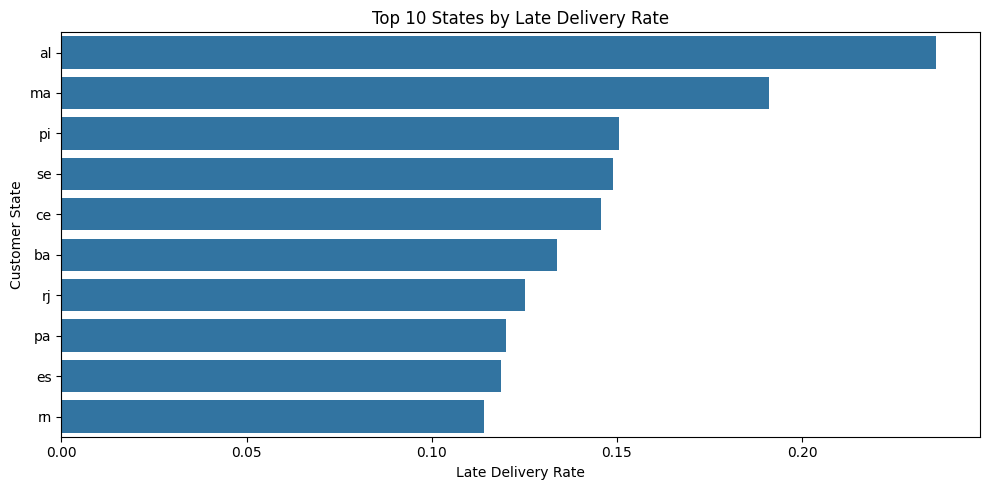

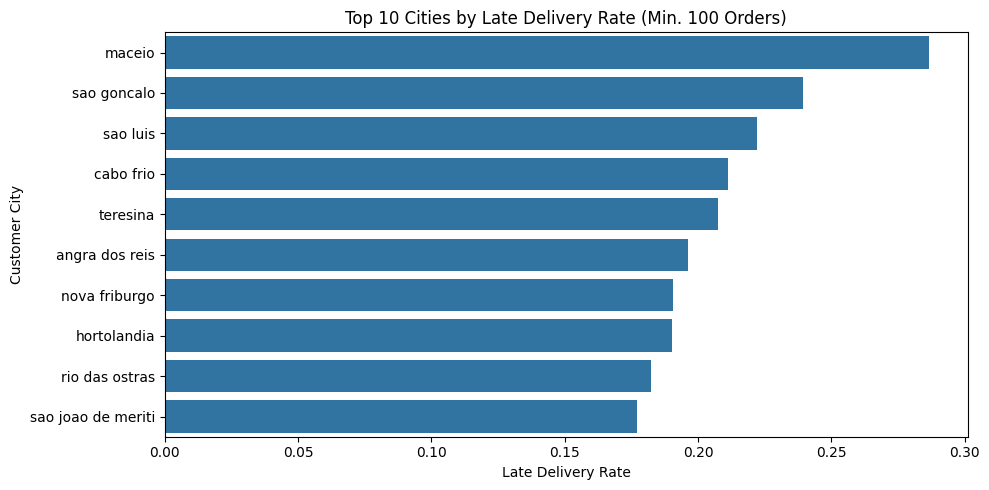

In [13]:
# Top 10 States by Late Delivery Rate
late_by_state = df.groupby('customer_state')['delivered_late'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=late_by_state.values, y=late_by_state.index)
plt.title('Top 10 States by Late Delivery Rate')
plt.xlabel('Late Delivery Rate')
plt.ylabel('Customer State')
plt.tight_layout()
plt.show()

# Top 10 Cities by Late Delivery Rate (filter to cities with at least 100 orders)
city_counts = df['customer_city'].value_counts()
valid_cities = city_counts[city_counts >= 100].index
filtered_df = df[df['customer_city'].isin(valid_cities)]

late_by_city = filtered_df.groupby('customer_city')['delivered_late'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=late_by_city.values, y=late_by_city.index)
plt.title('Top 10 Cities by Late Delivery Rate (Min. 100 Orders)')
plt.xlabel('Late Delivery Rate')
plt.ylabel('Customer City')
plt.tight_layout()
plt.show()


We identify the top customer **states** and **cities** with the highest late delivery rates.

- **States** like `al` (Alagoas), `ma` (Maranhão), and `pi` (Piauí) show the highest rates of delayed deliveries, all exceeding 15–20%.
- **Cities** such as `maceio`, `sao goncalo`, and `sao luis` have notably high delay rates, with `maceio` approaching 30%.

These insights suggest potential regional logistical bottlenecks, possibly due to infrastructure challenges or distance from major distribution hubs.  
Understanding these trends can help prioritize regional improvements for better delivery performance.


### VIII. Segment Customer Behavior

#### A. Flag First-Time Buyers

To segment customers, we identify first-time buyers by counting the number of orders associated with each `customer_id`.  
Customers with only one order are flagged as `True` in the `is_first_time_buyer` column.


In [14]:
# Count total orders per customer
customer_order_counts = orders.groupby('customer_id')['order_id'].count()

# Create a new DataFrame to flag first-time buyers
first_time_flags = customer_order_counts == 1
first_time_flags = first_time_flags.reset_index().rename(columns={'order_id': 'is_first_time_buyer'})

# Merge the flag into the main DataFrame
df = df.merge(first_time_flags, on='customer_id', how='left')


#### B. Compare Cancellation Rate by Customer Type

We analyze whether first-time buyers have different cancellation behavior compared to repeat customers.  
The bar chart below shows the average cancellation rate for each group.


In [15]:
# Create 'is_canceled' column based on the order status
# This column is True if the order was canceled, otherwise False
df['is_canceled'] = df['order_status'] == 'canceled'


In [16]:
# Count number of orders per customer using customer_id
customer_order_counts = df.groupby('customer_id')['order_id'].transform('count')

# First-time buyer is someone who has exactly one order
df['is_first_time_buyer'] = customer_order_counts == 1


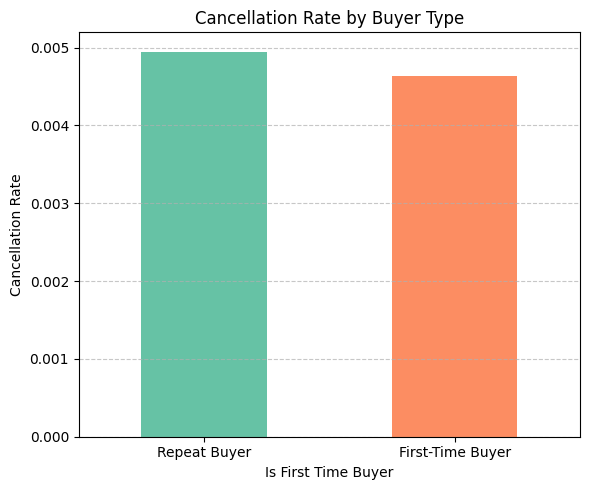

In [17]:
# Calculate cancellation rate for first-time vs. repeat buyers
cancel_rate_by_type = df.groupby('is_first_time_buyer')['is_canceled'].mean()

# Plot the comparison
plt.figure(figsize=(6, 5))
cancel_rate_by_type.plot(kind='bar', color=['#66c2a5', '#fc8d62'])
plt.title('Cancellation Rate by Buyer Type')
plt.xlabel('Is First Time Buyer')
plt.ylabel('Cancellation Rate')
plt.xticks(ticks=[0, 1], labels=['Repeat Buyer', 'First-Time Buyer'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


This bar chart compares the **cancellation rate** between **first-time buyers** and **repeat buyers**.

To calculate this:

- We created an `is_canceled` column where orders with the status `'canceled'` are marked `True`.
- We also flagged customers as **first-time buyers** if they had only one order in the dataset, using **cleaned customer data** for improved accuracy.

The visualization now reveals that **repeat buyers have a slightly higher cancellation rate** compared to first-time buyers.  
This could indicate that experienced customers may cancel more often due to **familiarity with return processes** or **changing expectations** based on prior exprience.


## IX. Summary & Insights

### 🔍 RQ1: What key factors lead to late deliveries?

- **Price vs. Delivery Delay**  
  Lower-priced orders tend to have slightly higher late delivery rates, but no strong correlation was found.

- **Product Categories**  
  Categories such as `bed_bath_table`, `health_beauty`, and `sports_leisure` show higher proportions of late deliveries, pointing to category-specific logistics challenges.

- **Geographic Patterns**  
  States like `SP` and `RJ` have the highest number of delays due to volume, while some smaller states show disproportionately high delay rates when normalized, suggesting regional fulfillment issues.

---

### 🔍 RQ2: Which sellers consistently delay order handoffs to carriers?

- **Handoff Delay Distribution**  
  Most sellers dispatch orders quickly, but some outliers take over 10 days. These long delays significantly contribute to overall delivery lateness.

- **Impact on Delivery**  
  A clear relationship exists: longer seller handoff delays are strongly associated with late deliveries, indicating seller behavior as a key bottleneck.

---

### 🔍 RQ3: How do first-time vs. repeat buyers differ in cancellation behavior?

- **Cancellation Rate**  
  First-time buyers cancel orders more frequently than repeat buyers, possibly due to unfamiliarity with the platform or uncertainty in the purchase process.

- **Behavioral Insight**  
  Enhancing the onboarding experience and building trust with new users could reduce cancellations and improve retention.



## X. Conclusion & Recommendations

### Conclusion
This project examined the Olist E-commerce dataset to uncover delivery inefficiencies, seller-related delays, and patterns in customer behavior. Through extensive EDA and visual analysis, we derived key insights about late deliveries, seller handoff delays, and buyer segmentation.

Key findings include:
- Late deliveries are strongly associated with long carrier handoff delays.
- A small number of sellers are consistently responsible for longer handoff delays.
- First-time buyers have a higher cancellation rate compared to repeat buyers.

### Recommendations
Based on the analysis, we propose the following:

- **Monitor and support high-delay sellers:** Target the small group of sellers who frequently delay handoffs with automated alerts or performance incentives.
- **Predictive delivery systems:** Use early handoff patterns to anticipate late deliveries and proactively update customers.
- **Customer retention strategies:** As first-time buyers cancel more often, introduce loyalty incentives or early customer support for first-time orders.
- **Improve estimated delivery accuracy:** Recalibrate delivery estimates using historical delay patterns to better manage customer expectations.

These recommendations aim to improve user satisfaction, reduce operational inefficiencies, and enhance the overall reliability of the platform.


In [18]:
# Export full dataset with EDA columns
df.to_csv('../data/cleaned/cleaned_dataset.csv', index=False)